In [1]:
# ============================================================
# CELL 0 — GLOBAL IMPORTS + PATH DETECTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.full as si
import os
from pathlib import Path
import json
import pandas as pd

# ============================================================
# USER INPUT: ONLY EDIT THIS ONE PATH
# ============================================================
kilosort_path = Path(r"xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")  ##########################################################

# ============================================================
# UNIFIED SESSION ROOT + ANALYSIS FOLDER DETECTION
# ============================================================

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find session root containing 'Record Node ...'")
        if any("Record Node" in d for d in os.listdir(parent)):
            return parent
        path = parent

def build_analysis_folder(session_root):
    session_date = session_root.parents[2].name
    experiment_name = session_root.parents[1].name
    recording_name = session_root.name

    folder_name = f"{session_date}_{experiment_name}_{recording_name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)

    subfolders = [
        "qc",
        "camera_alignment",
        "dlc_alignment",
        "behavior_ttls",
        "peak_detection",
        "metadata"
    ]
    for sf in subfolders:
        (analysis_folder / sf).mkdir(exist_ok=True)

    return analysis_folder

def get_analysis_folder_from_kilosort(kilosort_path):
    session_root = find_session_root(kilosort_path)
    return build_analysis_folder(session_root)

# Create analysis + QC folders
analysis_folder = get_analysis_folder_from_kilosort(kilosort_path)
qc_folder = analysis_folder / "qc"
qc_folder.mkdir(exist_ok=True)

print("Analysis folder:", analysis_folder)
print("QC folder:", qc_folder)


Detected session root: D:\Kevin\2026-03-04_08-31-33
Detected experiment: experiment1
Analyzer output folder: D:\Kevin\2026-03-04_08-31-33\sorting_analyzer_output


In [2]:
# ============================================================
# CELL 1 — VERIFY + LOAD RECORDING
# ============================================================

raw_data_path = find_session_root(kilosort_path)

print("\n=== PATH VERIFICATION ===")
print("Session folder exists:", raw_data_path.is_dir())

record_nodes = [f for f in os.listdir(raw_data_path) if "Record Node" in f]
print("Record Nodes found:", record_nodes)

def find_experiment_name(path):
    path = Path(path).resolve()
    for part in path.parts:
        if part.startswith("experiment"):
            return part
    raise RuntimeError("Could not detect experiment name")

experiment_name = find_experiment_name(kilosort_path)
print("Detected experiment:", experiment_name)

print(f"\nLoading Neuropixels stream from experiment '{experiment_name}'...")
recording = si.read_openephys(
    raw_data_path,
    experiment_name=experiment_name,
    stream_id='0'
)
recording = si.scale(recording)

print("\nLoaded recording:")
print(recording)
print("Sampling rate:", recording.sampling_frequency)
print("Num channels:", recording.get_num_channels())



=== PATH VERIFICATION ===
Session folder exists: True
Record Nodes found: ['Record Node 101', 'Record Node 104']
Checking D:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\structure.oebin: exists = True
Checking D:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\structure.oebin: exists = True

Loading Neuropixels stream from experiment 'experiment1'...

Loaded recording:
ScaleRecording: 384 channels - 30.0kHz - 1 segments - 73,418,682 samples 
                2,447.29s (40.79 minutes) - float32 dtype - 105.03 GiB
Sampling rate: 30000.0
Num channels: 384


In [3]:
# ============================================================
# CELL 2 — CREATE ANALYZER + FEATURE EXTRACTION (run once)
# ============================================================

analyzer_path = qc_folder / "sorting_analyzer_output"
analyzer_path.mkdir(exist_ok=True)

print("\nAnalyzer output folder:", analyzer_path)

print("Loading sorting...")
sorting = si.read_kilosort(kilosort_path)

print("Creating analyzer...")

analyzer = si.create_sorting_analyzer(
    sorting=sorting,
    recording=recording,
    folder=analyzer_path,
    format="binary_folder",
    overwrite=True
)

print("Computing FEATURES (run once)...")

analyzer.compute("random_spikes", max_spikes_per_unit=300)  ##########################################################
analyzer.compute("waveforms", ms_before=1.0, ms_after=2.0)  ##########################################################
analyzer.compute("noise_levels")

print("Feature extraction complete and cached.")


Loading sorting...
Creating analyzer...


estimate_sparsity (no parallelization):   0%|          | 0/2448 [00:00<?, ?it/s]

Computing FEATURES (run once)...


compute_waveforms (no parallelization):   0%|          | 0/2448 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

Feature extraction complete and cached.


In [4]:
# ============================================================
# CELL 3 — LOAD CACHED FEATURES (KILOSORT TEMPLATES ONLY)
# ============================================================

print("Loading cached SpikeInterface features...")

wfs_ext = analyzer.get_extension("waveforms")
noise_ext = analyzer.get_extension("noise_levels")

noise = noise_ext.get_data()

ks_templates = np.load(kilosort_path / "templates.npy")
ks_channel_map = np.load(kilosort_path / "channel_map.npy")
cluster_info = pd.read_csv(kilosort_path / "cluster_info.tsv", sep="\t")

cluster_col = "cluster_id" if "cluster_id" in cluster_info.columns else "id"
channel_col = "ch" if "ch" in cluster_info.columns else "channel"

phy_best_ch_id = {
    int(row[cluster_col]): int(row[channel_col])
    for _, row in cluster_info.iterrows()
}

whitening_inv = np.load(kilosort_path / "whitening_mat_inv.npy")
ks_templates_unwhitened = np.einsum("ij,utj->uti", whitening_inv, ks_templates)

phys_to_template_index = {phys_id: idx for idx, phys_id in enumerate(ks_channel_map)}

print("\nAll features loaded successfully ✔️")


Loading cached SpikeInterface features...

=== FEATURE LOAD SUMMARY ===
Kilosort templates shape: (390, 61, 384)
Noise array shape: (384,)
Number of units: 390
Unwhitened templates shape: (390, 61, 384)

All features loaded successfully ✔️


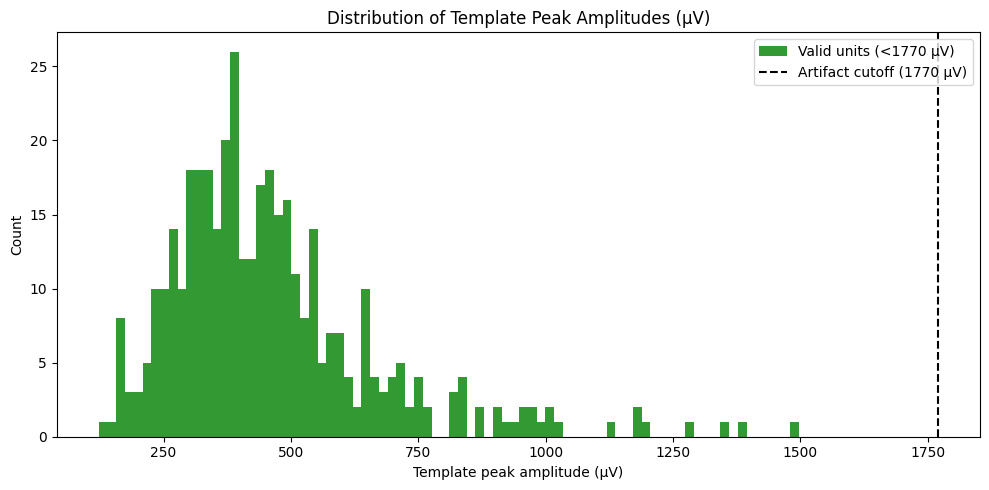


=== AMPLITUDE DISTRIBUTION SUMMARY ===
Total units: 390
Valid units (<1770 µV): 390
Artifact units (≥1770 µV): 0
Median amplitude (valid units): 419.67 µV
Max amplitude (valid units): 1497.42 µV

Artifact units: [] 


In [5]:
# ============================================================
# CELL 4 — AMPLITUDE DISTRIBUTION + ARTIFACT UNIT DETECTION (µV)
# ============================================================

unit_amp = {}

for uid in sorting.unit_ids:
    ks_idx = np.where(sorting.unit_ids == uid)[0][0]
    temp = ks_templates_unwhitened[ks_idx]
    best_ch_phys = phy_best_ch_id[uid]
    best_ch_idx = phys_to_template_index[best_ch_phys]
    waveform = temp[:, best_ch_idx]
    amp_uv = waveform.max() - waveform.min()
    unit_amp[uid] = amp_uv

amp_cutoff_uv = 1770  ##########################################################

amps = np.array([unit_amp[uid] for uid in sorting.unit_ids])
artifact_units = [uid for uid in sorting.unit_ids if unit_amp[uid] >= amp_cutoff_uv]
valid_units = [uid for uid in sorting.unit_ids if unit_amp[uid] < amp_cutoff_uv]

plt.figure(figsize=(10,5))
plt.hist(amps, bins=80, color='gray')
plt.axvline(amp_cutoff_uv, color='red', linestyle='--')
plt.title("Amplitude Distribution")
plt.xlabel("Amplitude (µV)")
plt.ylabel("Count")
plt.show()

qc_amp = {uid: ("FAIL_AMP" if uid in artifact_units else "PASS_AMP")
          for uid in sorting.unit_ids}


In [31]:
# ============================================================
# CELL 5 — PHY "Amplitude" FILTER USING cluster_info.tsv
# ============================================================

phy_amp_cutoff = 9.5  ##########################################################

ci = pd.read_csv(kilosort_path / "cluster_info.tsv", sep="\t")

phy_amp_from_info = {
    int(row["id"]): float(row["Amplitude"])
    for _, row in ci.iterrows()
}

phy_valid_units = [uid for uid in sorting.unit_ids if phy_amp_from_info.get(int(uid), 0.0) >= phy_amp_cutoff]
phy_artifact_units = [uid for uid in sorting.unit_ids if phy_amp_from_info.get(int(uid), 0.0) < phy_amp_cutoff]

qc_phy_amp = {uid: ("FAIL_PHYAMP" if uid in phy_artifact_units else "PASS_PHYAMP")
              for uid in sorting.unit_ids}



=== PHY Amplitude FILTER (from cluster_info.tsv) ===
Valid units (Amplitude >= 9.5): 336
Artifact units (Amplitude < 9.5): 88


In [41]:
# ============================================================
# CELL 6 — UNIFIED SHAPE QC: WIDTH + OSCILLATION
# ============================================================

sampling_rate = recording.sampling_frequency

min_width_ms = 0.13  ##########################################################
max_zerox = 4        ##########################################################
window_ms = 1.0      ##########################################################

unit_width_ms = {}
unit_zerox = {}
shape_artifact_units = []

win_samples = int(window_ms * sampling_rate / 1000)

for i, uid in enumerate(sorting.unit_ids):
    wf = ks_templates_unwhitened[i]
    neg_peaks = -np.min(wf, axis=0)
    best_ch = int(np.argmax(neg_peaks))
    trace = wf[:, best_ch]

    trough_idx = int(np.argmin(trace))
    trough_val = trace[trough_idx]
    half = trough_val / 2

    below = np.where(trace < half)[0]
    width_samples = (below[-1] - below[0]) if len(below) > 0 else 0
    width_ms = (width_samples / sampling_rate) * 1000
    unit_width_ms[uid] = width_ms

    start = max(0, trough_idx - win_samples // 2)
    end = min(len(trace), trough_idx + win_samples // 2)
    seg = trace[start:end] - np.mean(trace[start:end])
    signs = np.sign(seg)
    signs[signs == 0] = 1
    zerox = int(np.sum(signs[1:] != signs[:-1]))
    unit_zerox[uid] = zerox

    if width_ms < min_width_ms or zerox > max_zerox:
        shape_artifact_units.append(uid)

qc_wave = {uid: ("FAIL_WAVE" if uid in shape_artifact_units else "PASS_WAVE")
           for uid in sorting.unit_ids}



=== UNIFIED SHAPE QC: WIDTH + OSCILLATION (1-of-2 RULE) ===
Units flagged by shape QC (≥1 fail): 48
Example flagged units: [np.int64(2), np.int64(12), np.int64(32), np.int64(59), np.int64(90), np.int64(93), np.int64(102), np.int64(104), np.int64(109), np.int64(128)]


Computing SNR and amplitude QC using Kilosort templates...

=== AMPLITUDE FILTER RESULTS ===
Valid units (< 1770 µV): 421
Artifact units (≥ 1770 µV): 3

=== SNR QC SUMMARY (best channel) ===
Median noise (µV): 71.18547058105469
Median template peak (µV): 461.16294860839844
Median SNR: 6.5780675457132025

First 5 units:
Unit 0: best_ch=6, amp=241.6 µV, noise=72.1 µV, SNR=3.35
Unit 1: best_ch=6, amp=62.5 µV, noise=72.1 µV, SNR=0.87
Unit 2: best_ch=6, amp=352.3 µV, noise=72.1 µV, SNR=4.88
Unit 3: best_ch=1, amp=212.1 µV, noise=74.4 µV, SNR=2.85
Unit 4: best_ch=2, amp=257.8 µV, noise=77.1 µV, SNR=3.34


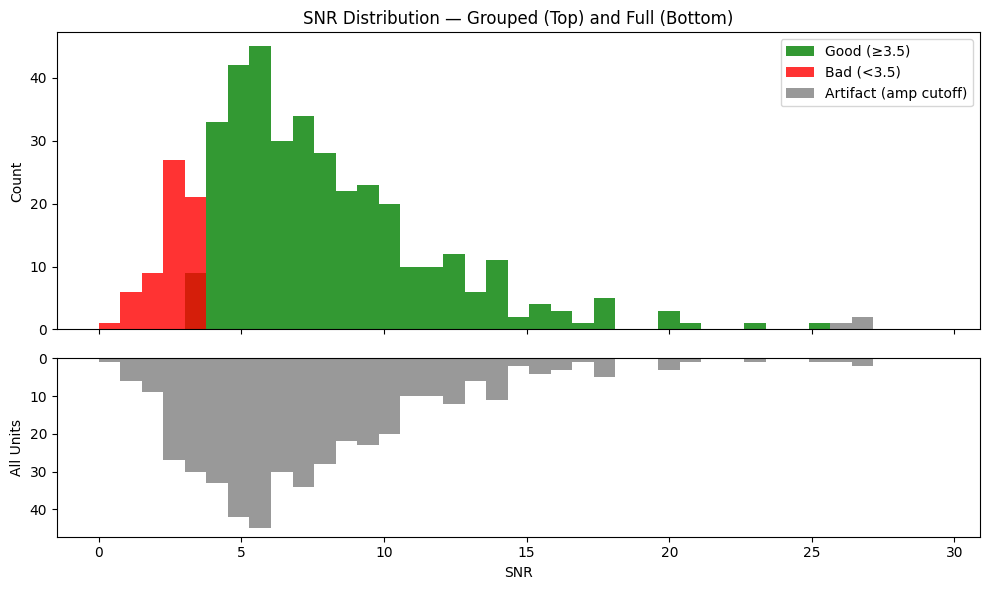

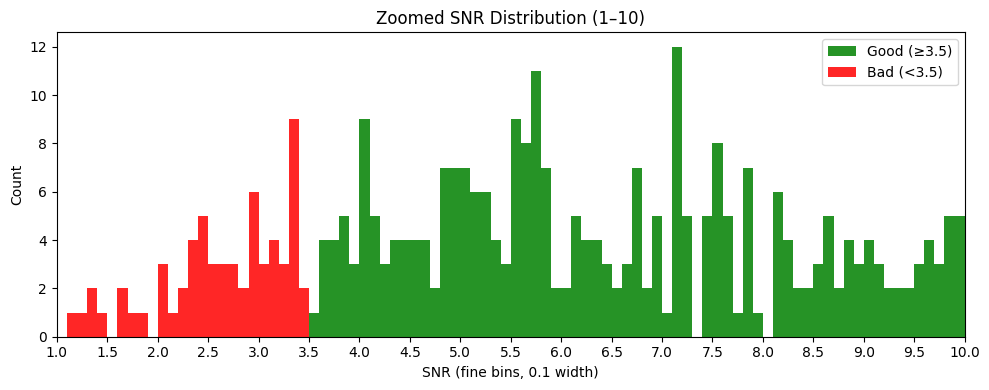


=== 10 UNITS AROUND MEDIAN SNR (median=6.46) ===
Unit 345: SNR=6.31, amp=467.3 µV, noise=74.1 µV, best_ch=314
Unit 329: SNR=6.31, amp=478.2 µV, noise=75.8 µV, best_ch=302
Unit 387: SNR=6.32, amp=420.7 µV, noise=66.5 µV, best_ch=359
Unit 316: SNR=6.38, amp=428.6 µV, noise=67.1 µV, best_ch=290
Unit 421: SNR=6.40, amp=425.8 µV, noise=66.5 µV, best_ch=359
Unit 20: SNR=6.44, amp=461.1 µV, noise=71.6 µV, best_ch=14
Unit 352: SNR=6.48, amp=436.2 µV, noise=67.3 µV, best_ch=323
Unit 270: SNR=6.58, amp=477.3 µV, noise=72.6 µV, best_ch=236
Unit 328: SNR=6.60, amp=500.1 µV, noise=75.8 µV, best_ch=302
Unit 168: SNR=6.62, amp=447.3 µV, noise=67.6 µV, best_ch=139

=== SNR QC CLASSIFICATION ===
SNR good units (≥3.5): 356
SNR bad units (<3.5): 64
Artifact units (amp ≥ 1770 µV): 3

First 5 SNR-good units: [np.int64(2), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
First 5 SNR-bad units: [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(9)]
First 5 artifact units: [np.int64(83), np.int

In [37]:
# ============================================================
# CELL 7 — SNR + TEMPLATE AMPLITUDE QC (KILOSORT TEMPLATES)
# ============================================================

amp_cutoff_uv = 1770  ##########################################################
snr_threshold = 3.5    ##########################################################

unit_best_ch = {}
unit_amp2 = {}
unit_noise = {}
unit_snr = {}

for i, uid in enumerate(sorting.unit_ids):
    templ = ks_templates_unwhitened[i]
    neg_peaks = -np.min(templ, axis=0)
    best_ch = int(np.argmax(neg_peaks))
    neg_peak = float(neg_peaks[best_ch])
    noise_best = float(noise[best_ch])
    snr = neg_peak / noise_best if noise_best > 0 else np.nan

    unit_best_ch[uid] = best_ch
    unit_amp2[uid] = neg_peak
    unit_noise[uid] = noise_best
    unit_snr[uid] = snr

valid_units = [uid for uid in sorting.unit_ids if unit_amp2[uid] < amp_cutoff_uv]
artifact_units = [uid for uid in sorting.unit_ids if unit_amp2[uid] >= amp_cutoff_uv]

snr_good_units = [uid for uid in valid_units if unit_snr[uid] >= snr_threshold]
snr_bad_units  = [uid for uid in valid_units if unit_snr[uid] <  snr_threshold]

qc_snr = {}
for uid in sorting.unit_ids:
    if uid in artifact_units:
        qc_snr[uid] = "SKIP_SNR_ARTIFACT"
    elif uid in snr_good_units:
        qc_snr[uid] = "PASS_SNR"
    else:
        qc_snr[uid] = "FAIL_SNR"


In [54]:
# ============================================================
# CELL 8 — POSITIVE DEFLECTION QC (KILOSORT TEMPLATES ONLY)
# ============================================================

pos_ratio_threshold = 0.9  ##########################################################

unit_pos_ratio = {}

for uid in sorting.unit_ids:
    main_ch_id = phy_best_ch_id[uid]
    if main_ch_id not in phys_to_template_index:
        unit_pos_ratio[uid] = np.inf
        continue

    main_idx = phys_to_template_index[main_ch_id]
    trace = ks_templates[uid][:, main_idx]

    neg = abs(np.min(trace))
    pos = abs(np.max(trace))

    unit_pos_ratio[uid] = pos / neg if neg > 0 else np.inf

pos_bad_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] >= pos_ratio_threshold]

qc_pos = {uid: ("FAIL_POS" if uid in pos_bad_units else "PASS_POS")
          for uid in sorting.unit_ids}


Computing positive deflection QC using Kilosort templates...

=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===
BAD units (pos/neg >= 0.9): 194
GOOD units (pos/neg <  0.9): 230

Example FAILED units (up to 15):
[np.int64(0), np.int64(1), np.int64(4), np.int64(5), np.int64(9), np.int64(12), np.int64(21), np.int64(24), np.int64(30), np.int64(31), np.int64(32), np.int64(36), np.int64(48), np.int64(49), np.int64(51)]


In [55]:
# ============================================================
# CELL 9 — SLIM + SAFE ISI + ACG QC
# ============================================================

rp_ms = 2.0         ##########################################################
isi_threshold = 0.01 ##########################################################

isi_metrics = {}
fs = recording.sampling_frequency

def compute_rpv(st_sec, rp_ms=1.0):
    if st_sec.size < 2:
        return np.nan
    isis = np.diff(st_sec)
    return np.sum(isis < (rp_ms / 1000.0)) / len(isis)

for uid in sorting.unit_ids:
    if uid in artifact_units:
        continue

    st_samples = sorting.get_unit_spike_train(uid)
    if st_samples.size < 2:
        isi_metrics[uid] = np.nan
        continue

    st_sec = st_samples / fs
    isi_metrics[uid] = compute_rpv(st_sec, rp_ms=rp_ms)

qc_isi = {}
for uid in sorting.unit_ids:
    if uid not in isi_metrics or np.isnan(isi_metrics[uid]):
        qc_isi[uid] = "SKIP_ISI"
    elif isi_metrics[uid] < isi_threshold:
        qc_isi[uid] = "PASS_ISI"
    else:
        qc_isi[uid] = "FAIL_ISI"


Computing ISI violations + ACG (memory‑safe)...

=== ISI QC SUMMARY ===
Good ISI units (<1.0% RPV): 340
Bad ISI units (≥1.0% RPV): 81

First 5 ISI metrics:
Unit 0: RPV=0.0020
Unit 1: RPV=0.0024
Unit 2: RPV=0.0010
Unit 3: RPV=0.0047
Unit 4: RPV=0.0000


In [57]:
# ============================================================
# cell 10: FINAL QC TABLE + VERDICT (MODULAR)
# ============================================================

qc_rows = []

for uid in sorting.unit_ids:
    amp_label = qc_amp.get(uid, "NA_AMP")
    phy_label = qc_phy_amp.get(uid, "NA_PHYAMP")
    snr_label = qc_snr.get(uid, "NA_SNR")
    isi_label = qc_isi.get(uid, "NA_ISI")
    pos_label = qc_pos.get(uid, "NA_POS")
    wave_label = qc_wave.get(uid, "NA_WAVE")

    if phy_label == "FAIL_PHYAMP":
        verdict = "REJECT"
        fail_count = "AUTO_FAIL_PHY"
    elif pos_label == "FAIL_POS":
        verdict = "REJECT"
        fail_count = "AUTO_FAIL_POS"
    else:
        labels = [amp_label, snr_label, isi_label, pos_label, wave_label]
        fail_count = sum(lbl.startswith("FAIL") for lbl in labels)
        verdict = "GOOD" if fail_count == 0 else ("CHECK" if fail_count == 1 else "REJECT")

    qc_rows.append({
        "unit": uid,
        "AMP": amp_label,
        "PHY_AMP": phy_label,
        "SNR": snr_label,
        "ISI": isi_label,
        "POS": pos_label,
        "WAVE": wave_label,
        "fail_count": fail_count,
        "verdict": verdict
    })

qc_df = pd.DataFrame(qc_rows).sort_values("unit").reset_index(drop=True)

print("\n=== FINAL QC VERDICT COUNTS ===")
print(qc_df["verdict"].value_counts())

qc_df.to_csv(qc_folder / "qc_table.csv", index=False)

with open(qc_folder / "qc_labels.json", "w") as f:
    json.dump({
        "qc_amp": qc_amp,
        "qc_phy_amp": qc_phy_amp,
        "qc_snr": qc_snr,
        "qc_isi": qc_isi,
        "qc_pos": qc_pos,
        "qc_wave": qc_wave
    }, f, indent=4)

print("\nQC saved to:", qc_folder)
print("QC MODULE COMPLETE ✔️")



=== FINAL QC VERDICT COUNTS ===
verdict
REJECT    248
GOOD      123
CHECK      53
Name: count, dtype: int64


,unit,AMP,PHY_AMP,SNR,ISI,POS,WAVE,fail_count,verdict
0,0,PASS_AMP,PASS_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,PASS_WAVE,AUTO_FAIL_POS,REJECT
1,1,PASS_AMP,FAIL_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,PASS_WAVE,AUTO_FAIL_PHY,REJECT
2,2,PASS_AMP,PASS_PHYAMP,PASS_SNR,PASS_ISI,PASS_POS,FAIL_WAVE,1,CHECK
3,3,PASS_AMP,PASS_PHYAMP,FAIL_SNR,PASS_ISI,PASS_POS,PASS_WAVE,1,CHECK
4,4,PASS_AMP,PASS_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,PASS_WAVE,AUTO_FAIL_POS,REJECT
5,5,PASS_AMP,PASS_PHYAMP,PASS_SNR,PASS_ISI,FAIL_POS,PASS_WAVE,AUTO_FAIL_POS,REJECT
6,6,PASS_AMP,FAIL_PHYAMP,PASS_SNR,PASS_ISI,PASS_POS,PASS_WAVE,AUTO_FAIL_PHY,REJECT
7,7,PASS_AMP,PASS_PHYAMP,PASS_SNR,PASS_ISI,PASS_POS,PASS_WAVE,0,GOOD
8,8,PASS_AMP,PASS_PHYAMP,PASS_SNR,PASS_ISI,PASS_POS,PASS_WAVE,0,GOOD
9,9,PASS_AMP,PASS_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,PASS_WAVE,AUTO_FAIL_POS,REJECT


In [ ]:
# ============================================================
# CELL 11 — REBUILD cluster_group.tsv FROM QC VERDICTS (CHECK → GOOD)
# ============================================================

import pandas as pd

cluster_group_path = kilosort_path / "cluster_group.tsv"

rows = []

for row in qc_df.itertuples():
    uid = int(row.unit)
    verdict = row.verdict

    # Map QC verdict → Phy label
    if verdict == "REJECT":
        group = "noise"      # Ctrl+N equivalent
    elif verdict == "CHECK":
        group = "good"       # CHECK now treated as GOOD
    elif verdict == "GOOD":
        group = "good"
    else:
        group = "good"

    rows.append({"cluster_id": uid, "group": group})

cg_new = pd.DataFrame(rows)
cg_new.to_csv(cluster_group_path, sep="\t", index=False)

print("Rebuilt cluster_group.tsv with", len(cg_new), "rows.")
print("CHECK units are now labeled as GOOD in Phy.")


In [ ]:
# SINGLE UNIT CHECKER #

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

def show_qc_for_unit(unit_id):
    row = qc_df[qc_df["unit"] == unit_id]
    if row.empty:
        print(f"Unit {unit_id} not found in QC table.")
    else:
        print(row.to_string(index=False))
        
def show_qc_for_unit(unit_id):
    row = qc_df[qc_df["unit"] == unit_id]
    if row.empty:
        print(f"Unit {unit_id} not found in QC table.")
        return
    
    r = row.iloc[0]
    print(f"Unit {unit_id} QC breakdown:")
    print(f"  AMP:       {r.AMP}")
    print(f"  PHY_AMP:   {r.PHY_AMP}")
    print(f"  SNR:       {r.SNR}")
    print(f"  ISI:       {r.ISI}")
    print(f"  POS:       {r.POS}")
    print(f"  Fail count:{r.fail_count}")
    print(f"  Verdict:   {r.verdict}")


show_qc_for_unit(23)